# Getting started with MemsArrayDB objects

The `MemsArrayDB` class allows getting signals from MemsArray saved in a remote database 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.core.db import MemsArrayDB

log.setLevel( "INFO" )

# Set database access credentials
#DBHOST = 'http://dbwelfare.biimea.io/'
DBHOST = 'http://dbchantier.biimea.io/'
LOGIN = 'ailab'
EMAIL = 'bruno.gas@biimea.com'
PASSWORD = '#T;uZnQ5UJ_JC~&'

## Starting with simple signals

One has only to specify the file identifier.

The ``MemsArrayDB`` constructor connects to the database and populates the antenna parameters with metadata received from the database. An exception is raised if connection failed.

In [2]:
# Choose the very first signal file of the database-
FILE_ID = 1201

# Define the antenna
antenna = MemsArrayDB( 
    dbhost=DBHOST, login=LOGIN, email=EMAIL, password=PASSWORD, 
    file_id=FILE_ID
)

2023-10-24 18:26:58,194 [INFO]:  .Install MemsArrayDB settings
2023-10-24 18:26:58,197 [INFO]:  .Created a new antenna
2023-10-24 18:26:58,199 [INFO]:  .Install MemsArrayDB settings
2023-10-24 18:26:58,201 [INFO]:  .Try connecting on endpoint database http://dbchantier.biimea.io//dj-rest-auth/login/...
2023-10-24 18:26:58,595 [INFO]:  .Got HTTP 200 status code from server
2023-10-24 18:26:58,596 [INFO]:  .Received CSRF token: B2PD1SqkGjNBKIdN4Y4s9i9VASERHSgO. Update session with
2023-10-24 18:26:58,596 [INFO]:  .Received session id: pb96azqb4rlsuojg2n91trdolcjrwaq0
2023-10-24 18:26:58,597 [INFO]:  .Successfully connected on http://dbchantier.biimea.io/
2023-10-24 18:26:58,597 [INFO]:  .Downloading metadata for object 'sourcefile' [1201]...
2023-10-24 18:26:58,598 [INFO]:  .Send a database request on endpoint: http://dbchantier.biimea.io//sourcefile/1201
2023-10-24 18:26:58,638 [INFO]:  .Object sourcefile found with identifier [1201] 
2023-10-24 18:26:58,639 [INFO]:  .Set 24 available M

You can get now some Meta informations regarding the file

In [3]:
print( f"Sampling frequency: {antenna.sampling_frequency}Hz" )
print( f"Available MEMs number: {antenna.available_mems_number}" )
print( f"Whether counter is available or not: {antenna.counter}" )

Sampling frequency: 25000.0Hz
Available MEMs number: 24
Whether counter is available or not: True


## Getting and plotting some MEMs signals

You can select some MEMs you would like to plot and get signals on a given range time (10 seconds in this example)

In [ ]:
# Run antenna
antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    counter_skip = True,
    datatype='float32'
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"exit from loop. Signal shape is: {np.shape( signals )}" )

Here is the ploting program

In [ ]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wave file
TO BE REVIEWED !!!

In [ ]:
import wave

WAV_FILENAME = 'titi.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [5, 6],
    duration=20,
    counter_skip = True,
    datatype='int32'
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='C' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

## Hearing signal with *pyaudio* library

In [4]:
import pyaudio

FRAME_LENGTH = 256

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[0, 1],
    duration=30,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    datatype='int32'
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ) * antenna.sensibility )

    # write into audio stream
    stream.write( data.tobytes( order='C'), num_frames=FRAME_LENGTH )
    transfers_counter += 1


# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()

print( f"Exit from loop with {transfers_counter} transfers" )

2023-10-24 18:27:27,263 [INFO]:  .Starting run execution
2023-10-24 18:27:27,265 [INFO]:  .Install MemsArray settings
2023-10-24 18:27:27,267 [INFO]:  .2 MEMs were activated among 0 to 23 available MEMs
2023-10-24 18:27:27,269 [INFO]:  .Set datatype to int32 
2023-10-24 18:27:27,272 [INFO]:  .Install MemsArrayDB settings
2023-10-24 18:27:27,273 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-24 18:27:27,275 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-10-24 18:27:27,278 [INFO]:  .Perform a 30s run loop
2023-10-24 18:27:27,284 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-10-24 18:27:27,287 [INFO]:  .Sampling frequency: 25000.0 Hz
2023-10-24 18:27:27,291 [INFO]:  .Active MEMs: [0, 1]
2023-10-24 18:27:27,297 [INFO]:  .Active analogic channels: []
2023-10-24 18:27:27,300 [INFO]:  .Whether counter is active: True
2023-10-24 18:27:27,301 [INFO]:  .Skipping counter: True
2023-10-24 18:27:27,306 [INFO]:  .Opening DB file on endpoint http://dbchantie

Exit from loop with 2287 transfers


2023-10-24 18:27:57,307 [INFO]:  .Thread timer started for 30s duration


## Getting labelized signals

You can obtain labelled signals from the base by specifying the necessary parameters: 
* The label identifier
* The file identifier where labeled signals are
* The sequence identifier 

In [8]:
# choose label, file and sequence in file:
LABEL_ID = 18
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0  

# Define the antenna
antenna = MemsArrayDB( 
    dbhost=DBHOST, login=LOGIN, email=EMAIL, password=PASSWORD, 
    label_id=LABEL_ID, file_id=FILE_ID, sequence_id=SEQUENCE_ID
)

2023-10-16 11:26:42,451 [INFO]:  .Install MemsArrayDB settings
2023-10-16 11:26:42,452 [INFO]:  .Created a new antenna
2023-10-16 11:26:42,455 [INFO]:  .Install MemsArrayDB settings
2023-10-16 11:26:42,458 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io//dj-rest-auth/login/...
2023-10-16 11:26:42,822 [INFO]:  .Got HTTP 200 status code from server
2023-10-16 11:26:42,823 [INFO]:  .Received CSRF token: zxvTQhXWdYUlFb45zv1YHzB770dU8rAI. Update session with
2023-10-16 11:26:42,824 [INFO]:  .Received session id: w05c52dbxjq85soctujh5xvkimye69ap
2023-10-16 11:26:42,825 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-10-16 11:26:42,825 [INFO]:  .Downloading metadata for object 'sourcefile' [8692]...
2023-10-16 11:26:42,827 [INFO]:  .Send a database request on endpoint: http://dbwelfare.biimea.io//sourcefile/8692
2023-10-16 11:26:42,894 [INFO]:  .Object sourcefile found with identifier [8692] 
2023-10-16 11:26:42,895 [INFO]:  .Set 32 available MEMs

## Plotting

2023-10-16 11:27:17,373 [INFO]:  .Starting run execution
2023-10-16 11:27:17,379 [INFO]:  .Install MemsArray settings
2023-10-16 11:27:17,382 [INFO]:  .7 MEMs were activated among 0 to 31 available MEMs
2023-10-16 11:27:17,383 [INFO]:  .Set datatype to float32 
2023-10-16 11:27:17,384 [INFO]:  .Install MemsArrayDB settings
2023-10-16 11:27:17,385 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-16 11:27:17,386 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-10-16 11:27:17,387 [INFO]:  .Perform a 10s run loop
2023-10-16 11:27:17,388 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-10-16 11:27:17,389 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-16 11:27:17,390 [INFO]:  .Active MEMs: [0, 1, 2, 3, 4, 5, 6]
2023-10-16 11:27:17,391 [INFO]:  .Active analogic channels: []
2023-10-16 11:27:17,392 [INFO]:  .Whether counter is active: True
2023-10-16 11:27:17,393 [INFO]:  .Skipping counter: True
2023-10-16 11:27:17,395 [INFO]:  .Opening DB file on endpoint

exit from loop, signal shape is: (90001, 7)


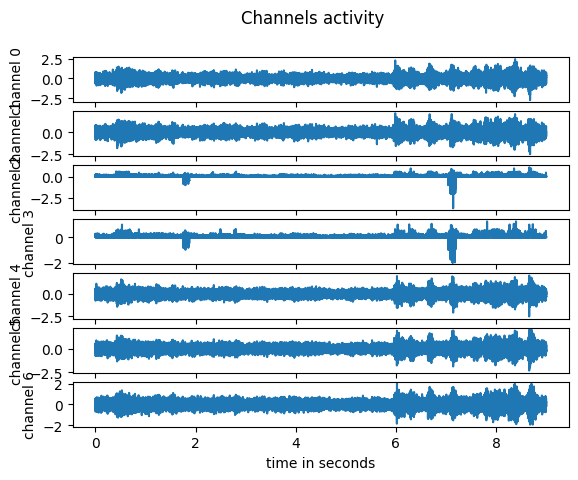

In [9]:
# 2 seconds run, getting signals from MEMs 1 and 2

antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
    counter_skip = True,
    datatype='float32'
)

signals = np.ndarray( (0, antenna.channels_number ) )

for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

print( f"exit from loop, signal shape is: {np.shape( signals )}" )

# waiting for the end of the running thread is mandatory
antenna.wait()

# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()



## Hearing

In [10]:
import pyaudio

FRAME_LENGTH = 256

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[0, 1],
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    datatype='int32'
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ) * antenna.sensibility )

    # write into audio stream
    stream.write( data.tobytes( order='C'), num_frames=FRAME_LENGTH )
    transfers_counter += 1


# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()

print( f"Exit from loop with {transfers_counter} transfers" )

2023-10-16 11:29:16,638 [INFO]:  .Starting run execution
2023-10-16 11:29:16,639 [INFO]:  .Install MemsArray settings
2023-10-16 11:29:16,640 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-16 11:29:16,641 [INFO]:  .Set datatype to int32 
2023-10-16 11:29:16,642 [INFO]:  .Install MemsArrayDB settings
2023-10-16 11:29:16,642 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-16 11:29:16,643 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-10-16 11:29:16,644 [INFO]:  .Perform a 10s run loop
2023-10-16 11:29:16,645 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-10-16 11:29:16,645 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-16 11:29:16,646 [INFO]:  .Active MEMs: [0, 1]
2023-10-16 11:29:16,647 [INFO]:  .Active analogic channels: []
2023-10-16 11:29:16,647 [INFO]:  .Whether counter is active: True
2023-10-16 11:29:16,648 [INFO]:  .Skipping counter: True
2023-10-16 11:29:16,649 [INFO]:  .Opening DB file on endpoint http://dbwelfare

Exit from loop with 352 transfers


## Getting counter 

You just have to set `counter_skip` to `False`

In [ ]:
antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
    counter_skip = False,
    datatype='float32'
)

counter = ( signals[:,0]/antenna.sensibility ).tobytes()
counter = np.frombuffer( counter, dtype=np.int32 )

print( counter )

2023-10-16 11:29:48,410 [INFO]:  .Starting run execution
2023-10-16 11:29:48,412 [INFO]:  .Install MemsArray settings
2023-10-16 11:29:48,416 [INFO]:  .7 MEMs were activated among 0 to 31 available MEMs
2023-10-16 11:29:48,418 [INFO]:  .Set datatype to float32 
2023-10-16 11:29:48,420 [INFO]:  .Install MemsArrayDB settings
2023-10-16 11:29:48,422 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-16 11:29:48,423 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-10-16 11:29:48,424 [INFO]:  .Perform a 10s run loop
2023-10-16 11:29:48,425 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-10-16 11:29:48,427 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-16 11:29:48,431 [INFO]:  .Active MEMs: [0, 1, 2, 3, 4, 5, 6]
2023-10-16 11:29:48,434 [INFO]:  .Active analogic channels: []
2023-10-16 11:29:48,439 [INFO]:  .Whether counter is active: True
2023-10-16 11:29:48,448 [INFO]:  .Skipping counter: False
2023-10-16 11:29:48,452 [INFO]:  .Opening DB file on endpoin

[  80246592 1089459712  386264077 ... 1087881215          0          0]


2023-10-16 11:29:48,492 [INFO]:  .Got positive response from server with for application/octet-stream data of 2880032 bytes length
2023-10-16 11:29:48,493 [INFO]:  .Start receiving 351 paquets of size 256 x 8
2023-10-16 11:29:48,494 [INFO]:  .Last chunk will carry 145 remaining samples
2023-10-16 11:29:55,632 [INFO]:  .Elapsed time: 7.180209159851074s (expected duration was: 10 s)
2023-10-16 11:29:55,633 [INFO]:  .Proceeded to 352 transfers
2023-10-16 11:29:55,633 [INFO]:  .Run completed
2023-10-16 11:29:58,456 [INFO]:  .Thread timer started for 10s duration


## Performing beamforming

TO DO...